# Laboratorio de teoría de control

UNIVERSIDAD DE ANTIOQUIA - FACULTAD DE INGENIERÍA - BIOINGENIERÍA

TEORIA DE CONTROL I – 2523720

Jenny Kateryne Aristizábal Nieto - 
Nataly Rodriguez Atehortua - 
Sebastian Zapata Rodríguez



En esta primera práctica de teoría de control nos acercaremos a una de las herramientas que utilizaremos a lo largo del semestre para analizar y simular sistemas dinámicos: la librería control de Python. El propósito de esta actividad no es profundizar en el diseño de controladores todavía, sino explorar las funciones básicas que nos ofrece la librería para representar sistemas, obtener sus respuestas y visualizar su comportamiento frente a distintas señales.

A lo largo del cuaderno iremos recorriendo algunos de los conceptos fundamentales del curso, apoyándonos en ejemplos prácticos:

1. **Definición de funciones de transferencia:** cómo representar un sistema dinámico en Python.
2. **Diagramas de polos y ceros:** herramienta gráfica inicial para estudiar estabilidad y comportamiento.
3. **Criterio de estabilidad:** comprobación básica de la estabilidad de un sistema.
4. **Respuestas en el tiempo:** análisis de cómo el sistema responde a entradas como el escalón, el impulso, la rampa, una senoidal o una señal cuadrada.
5. **Lazo abierto vs lazo cerrado:** comparación de configuraciones para entender el rol de la retroalimentación.
6. **Lugar geométrico de las raíces:** recurso visual clave para estudiar el efecto de parámetros en estabilidad y desempeño.
7. **Análisis en frecuencia:** otra perspectiva para comprender la dinámica del sistema.
8. **Discretización de señales:** cómo representar sistemas continuos en tiempo discreto mediante métodos como ZOH y Tustin.

El objetivo es que los estudiantes conozcan la librería, exploren sus funciones y se familiaricen con la sintaxis.

## Revisión: Phyton y librerías esenciales para el análisis de control

### Instalación de las librerías

In [1]:
!pip install control

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/578.3 kB ? eta -:--:--
   ---------------------------------------- 578.3/578.3 kB 4.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.5 MB ? eta -:--:--
    --------------------------------------- 0.8/38.5 MB 4.8 MB/s eta 0:00:08
   - -------------------------------------- 1.8/38.5 MB 4.8 MB/s eta 0:00:08
   -- ------------------------------------- 2.9/38.5 MB 4.9 MB/s eta 0:00:08
   ---- ----------------------------------- 4.2/38.5 MB 5.5 MB/s eta 0:00:07
   ----- ---------------------------------- 5.5/38.5 MB 5.7 MB/s eta 0:00:06
   ------- -------------------------------- 6.8/38.5 MB 5.8 MB/s eta 0:00:06
   -------- ------------------------------- 8.4/38.5 MB 6.0 MB/s eta 0:00:06
   ---------- ----------------------------- 10.0/38.5 MB 6.2 MB/s eta 0:00:05
   ------------ --------------------------- 11.8/38.5 MB 6.5 MB/s eta 0:00:05
   ---


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Importación de las librerías

In [2]:
import control as ct
from control.matlab import *   # funciones estilo MATLAB
import numpy as np
import matplotlib.pyplot as plt

### Definición de una función de transferencia

Ejemplo: G(s) = 5 / (s^2 + 2s + 5)

In [30]:
num = [5]
den = [1, 2, 5]
G = tf(num, den)
print("Función de transferencia G(s):")
print(G)


# Polos y ceros
print("Polos:", pole(G))
print("Ceros:", zero(G))

Función de transferencia G(s):
<TransferFunction>: sys[62]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        5
  -------------
  s^2 + 2 s + 5
Polos: [-1.+2.j -1.-2.j]
Ceros: []


### diagrama de polos y ceros

C:\Users\SEBASTIAN\AppData\Roaming\Python\Python312\site-packages\control\pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


Text(0.5, 1.0, 'Diagrama de Polos y Ceros')

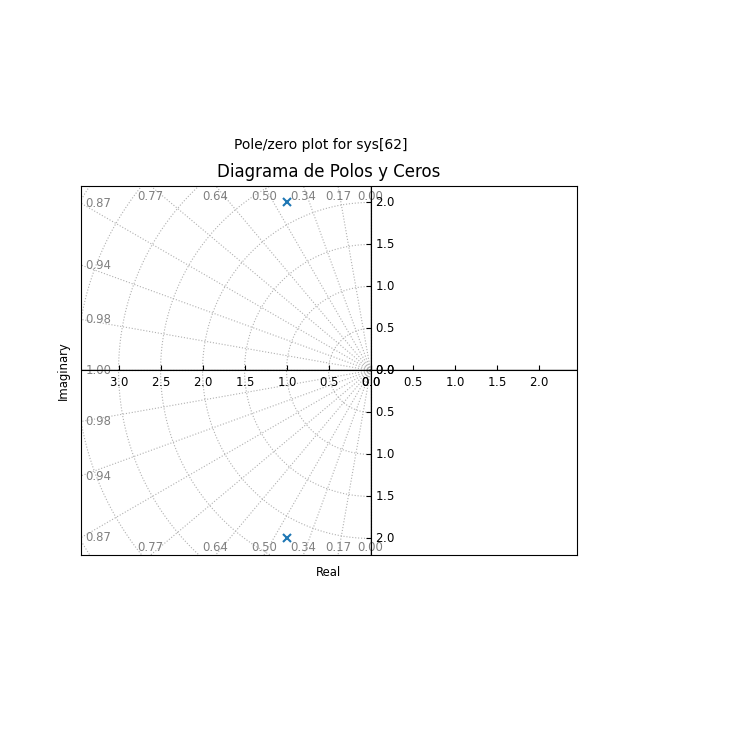

In [31]:
plt.figure()
pzmap(G, plot=True, grid=True)
plt.title("Diagrama de Polos y Ceros")

### Criterio de estabilidad

In [43]:
poles = pole(G)
print("\nPolos del sistema:", poles)
if np.all(np.real(poles) < 0):
    print("El sistema es ESTABLE.")
else:
    print("El sistema es INESTABLE.")


Polos del sistema: [-1.+2.j -1.-2.j]
El sistema es ESTABLE.


### Respuesta en el tiempo: Señales básicas

C:\Users\SEBASTIAN\AppData\Roaming\Python\Python312\site-packages\control\timeresp.py:1082: UserWarning: return_x specified for a transfer function system. Internal conversion to state space used; results may meaningless.
  warnings.warn(


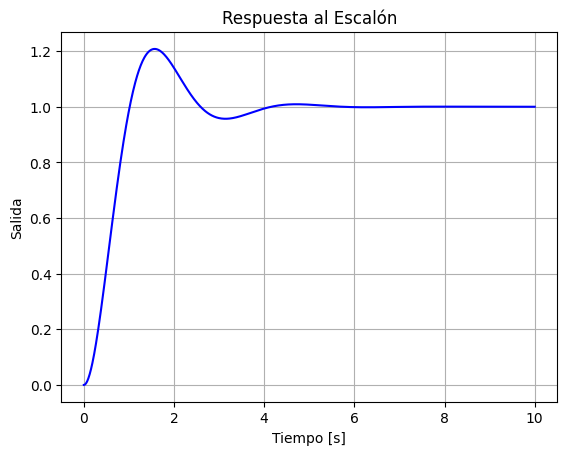

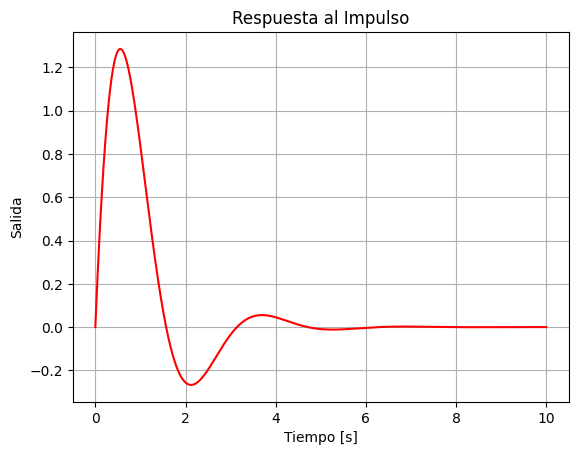

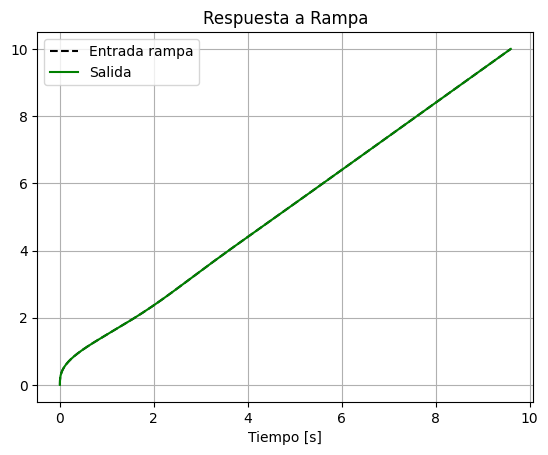

In [32]:
t = np.linspace(0, 10, 1000)

# --- Escalón ---
y1, t1 = step(G, T=t)   # OJO: primero y, luego t
plt.figure()
plt.plot(t1, y1, 'b')
plt.title("Respuesta al Escalón")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.grid()

# --- Impulso ---
y2, t2 = impulse(G, T=t)  # igual, primero y
plt.figure()
plt.plot(t2, y2, 'r')
plt.title("Respuesta al Impulso")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.grid()

# --- Rampa ---
u_ramp = t
t3, y3, _ = lsim(G, U=u_ramp, T=t)  # aquí sí regresa (t, y, x)
plt.figure()
plt.plot(t3, u_ramp, 'k--', label="Entrada rampa")
plt.plot(t3, y3, 'g', label="Salida")
plt.title("Respuesta a Rampa")
plt.xlabel("Tiempo [s]")
plt.legend()
plt.grid()






### Respuesta en el tiempo: Señal senosoidal y cuadrada

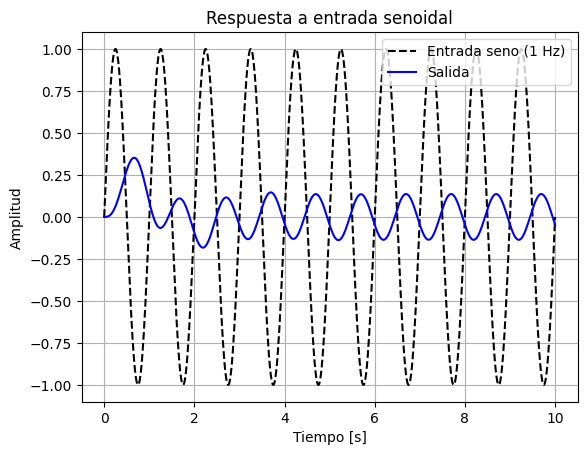

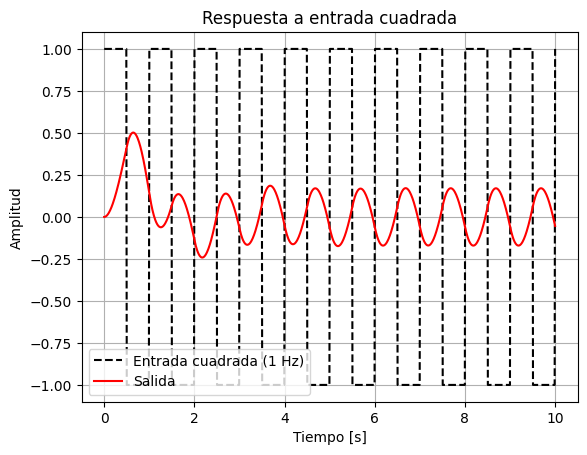

In [34]:
# --- Entrada senoidal ---
u_sin = np.sin(2*np.pi*1*t)  # seno de 1 Hz
y_sin, t_sin, x_sin = lsim(G, U=u_sin, T=t)

plt.figure()
plt.plot(t, u_sin, 'k--', label="Entrada seno (1 Hz)")
plt.plot(t_sin, y_sin, 'b', label="Salida")
plt.title("Respuesta a entrada senoidal")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()

# --- Entrada cuadrada ---
# square() genera valores entre -1 y 1, aquí frecuencia = 1 Hz
from scipy import signal
u_square = signal.square(2*np.pi*1*t)  
y_square, t_square, x_square = lsim(G, U=u_square, T=t)

plt.figure()
plt.plot(t, u_square, 'k--', label="Entrada cuadrada (1 Hz)")
plt.plot(t_square, y_square, 'r', label="Salida")
plt.title("Respuesta a entrada cuadrada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()

plt.show()


### Lazo abierto vs Lazo cerrado


Función de transferencia en lazo cerrado:
<TransferFunction>: sys[83]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        5
  --------------
  s^2 + 2 s + 10


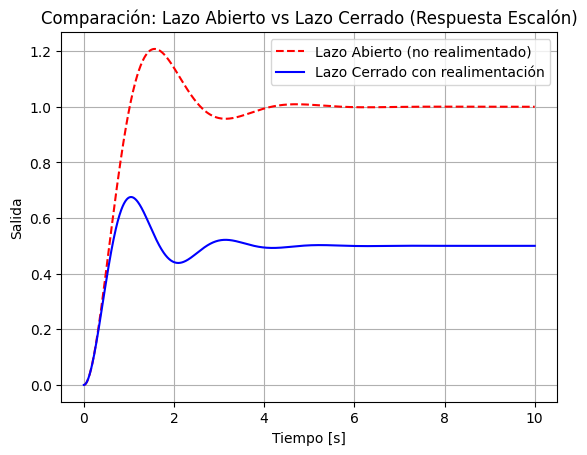

In [38]:
# Función de transferencia de lazo abierto
L = G  # lazo abierto

# Lazo cerrado con realimentación unitaria
T = feedback(L, 1)
print("\nFunción de transferencia en lazo cerrado:")
print(T)

# Comparación de respuesta al escalón
y_open, t1 = step(L, T=t)     # OJO: esta no es la salida real, solo la dinámica en lazo abierto
y_closed, t2 = step(T, T=t)

plt.figure()
plt.plot(t1, y_open, 'r--', label="Lazo Abierto (no realimentado)")
plt.plot(t2, y_closed, 'b', label="Lazo Cerrado con realimentación")
plt.title("Comparación: Lazo Abierto vs Lazo Cerrado (Respuesta Escalón)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.legend()
plt.grid()

### Lugar geométrico de las raíces

C:\Users\SEBASTIAN\AppData\Roaming\Python\Python312\site-packages\control\rlocus.py:202: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(


Text(0.5, 1.0, 'Lugar Geométrico de las Raíces')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


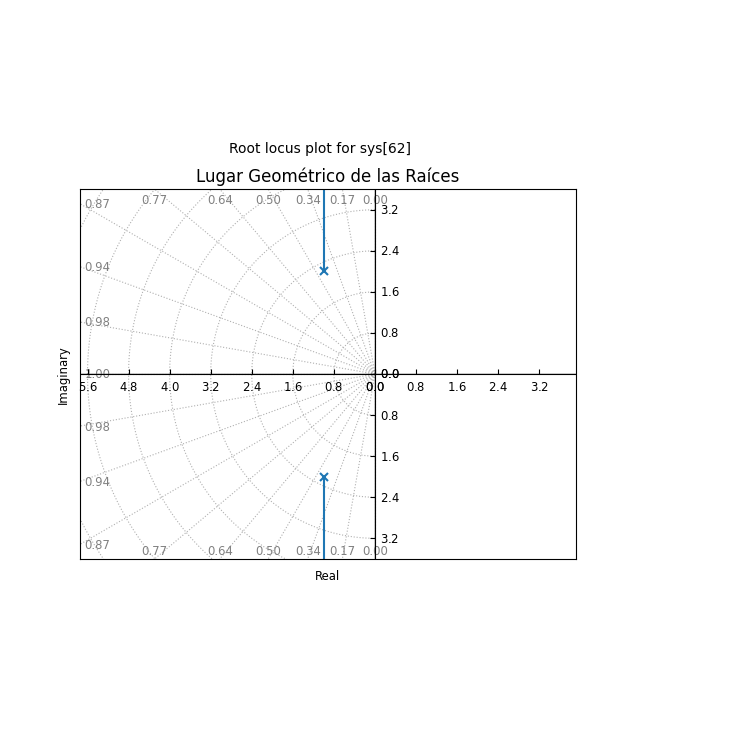

In [39]:
plt.figure()
rlocus(G)
plt.title("Lugar Geométrico de las Raíces")

### Análisis en frecuencia

C:\Users\SEBASTIAN\AppData\Roaming\Python\Python312\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


Margen de ganancia: inf, frecuencia: nan rad/s
Margen de fase: 78.46°, frecuencia: 2.45 rad/s


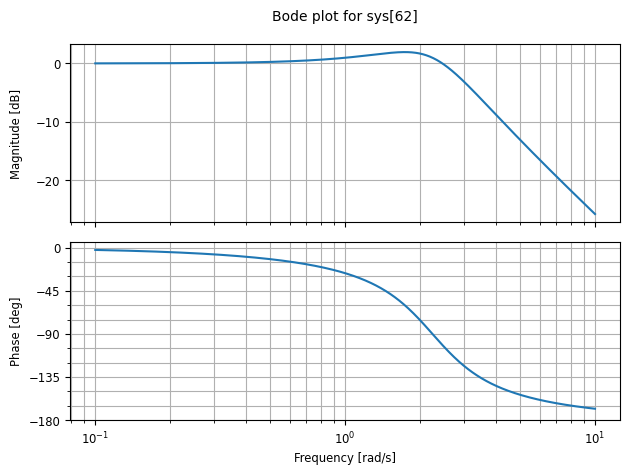

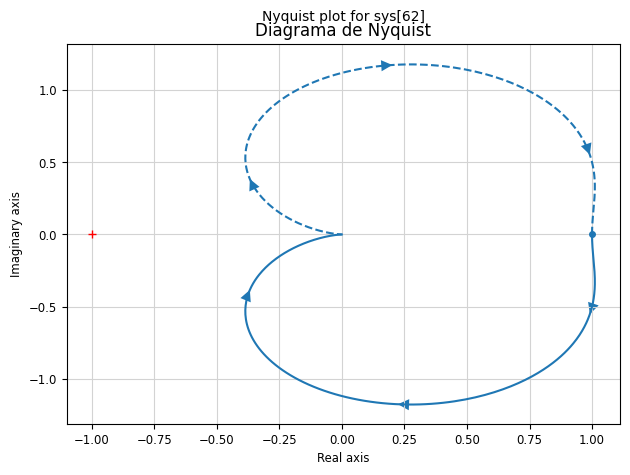

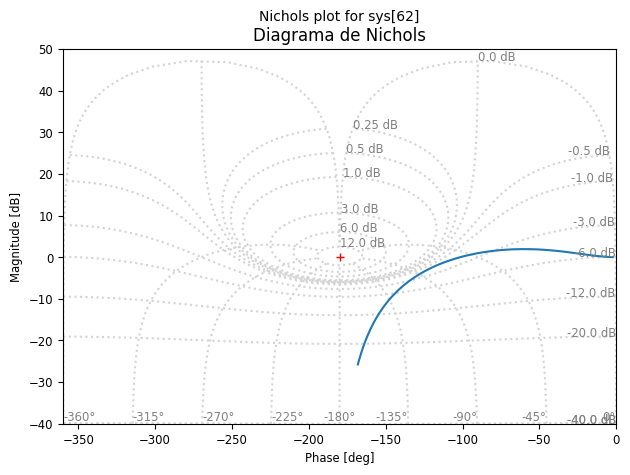

In [40]:
# Bode
plt.figure()
mag, phase, omega = bode(G, dB=True)

# Nyquist
plt.figure()
nyquist(G)
plt.title("Diagrama de Nyquist")

# Nichols
plt.figure()
nichols(G)
plt.title("Diagrama de Nichols")

# Margen de ganancia y fase
gm, pm, wg, wp = margin(G)
print(f"Margen de ganancia: {gm:.2f}, frecuencia: {wg:.2f} rad/s")
print(f"Margen de fase: {pm:.2f}°, frecuencia: {wp:.2f} rad/s")

### Discretización de una señal continua

Métodos disponibles en c2d():

1. **"foh"** (First-Order Hold)
2. **"matched"** (Emparejamiento de polos y ceros)
3. **"impulse"** (Ajuste por respuesta al impulso)
4. **"zoh"** (Zero-Order Hold)
5. **"tustin"** (Transformada Bilineal)


Sistema Discreto (ZOH):
<TransferFunction>: sys[62]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

   0.02332 z + 0.02181
  ----------------------
  z^2 - 1.774 z + 0.8187

Sistema Discreto (Tustin):
<TransferFunction>: sys[62]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

  0.01124 z^2 + 0.02247 z + 0.01124
  ---------------------------------
       z^2 - 1.775 z + 0.8202


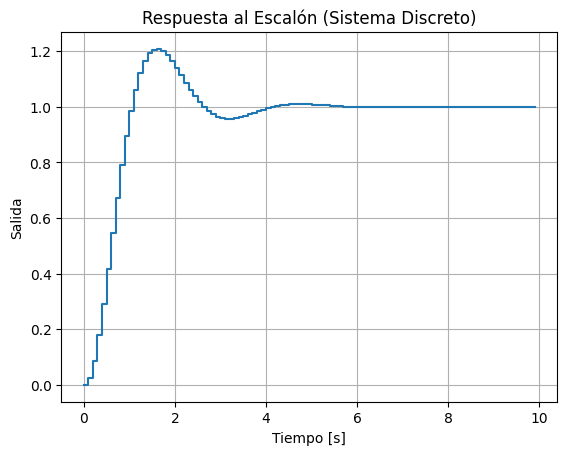

In [42]:
Ts = 0.1  # tiempo de muestreo
Gz_zoh = c2d(G, Ts, method='zoh')
Gz_tustin = c2d(G, Ts, method='tustin')
print("\nSistema Discreto (ZOH):")
print(Gz_zoh)
print("\nSistema Discreto (Tustin):")
print(Gz_tustin)

# Respuesta discreta al escalón
t_disc = np.arange(0, 10, Ts)
y6, t6 = step(Gz_zoh, T=t_disc)
plt.figure()
plt.step(t6, y6, where='post')
plt.title("Respuesta al Escalón (Sistema Discreto)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.grid()